# **Lab Exercise 5: Linear Regression through Gradient Descent**

**Student Name**: Achindra Sharma
**Roll Number**: 2547105

---
### **Aim**
To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on the UCI Student Performance dataset.

### **Dataset**
**Name**: Student Performance Dataset | **Source**: UCI Machine Learning Repository
**Link**: https://archive.ics.uci.edu/dataset/320/student+performance

### **Tasks to Perform**
1. Download and load the Student Performance dataset.
2. Perform data preprocessing — handle missing values (if any), encode categorical variables, and scale features.
3. Select appropriate input features and the target variable.
4. Split the dataset into training and testing sets.
5. Implement Linear Regression using the Gradient Descent algorithm.
6. Experiment with different learning rates and observe their effect on model convergence.
7. Plot the loss (cost) versus the number of iterations.
8. Evaluate the trained model using MAE, MSE, RMSE, and R² Score.
9. Interpret the results and comment on the convergence behavior and prediction performance of the model.

*Note: the reference template (`question.ipynb`) demonstrates these same steps on the single-feature Diabetes/BMI dataset; here every step is adapted to the assigned multi-feature Student Performance dataset.*

## **Part 1: Library Imports & Environment Setup**
We import standard packages for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and the machine learning utilities from `scikit-learn` used for splitting, scaling, and metric computation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["font.size"] = 11
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

print("All packages imported successfully!")

All packages imported successfully!


* Libraries loaded for data handling, visualization, and preprocessing/metric utilities.
* Random seed fixed at 42 so every result in this notebook is reproducible.

## **Task 1: Download and Load the Dataset**
We load the UCI Student Performance dataset (`student-mat.csv`, semicolon-separated), inspect its size, and check for missing values so we know exactly what preprocessing is needed in Task 2.

In [2]:
df = pd.read_csv('student-mat.csv', sep=';')

print("=== DATASET OVERVIEW ===")
print(f"Shape of dataset: {df.shape}")
print(f"Missing values in dataset: {df.isnull().sum().sum()}")
print(f"Duplicate rows in dataset: {df.duplicated().sum()}")

print("\nTarget Variable (G3) Summary Statistics:")
print(df['G3'].describe())

df.head()

=== DATASET OVERVIEW ===
Shape of dataset: (395, 33)
Missing values in dataset: 0
Duplicate rows in dataset: 0

Target Variable (G3) Summary Statistics:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


* Dataset contains **395 students** with **33 raw columns**, and **zero missing values or duplicates** — no imputation or deduplication is needed.
* Target $G3$ (final grade) ranges 0–20 with mean $\approx 10.4$, giving enough spread to model.

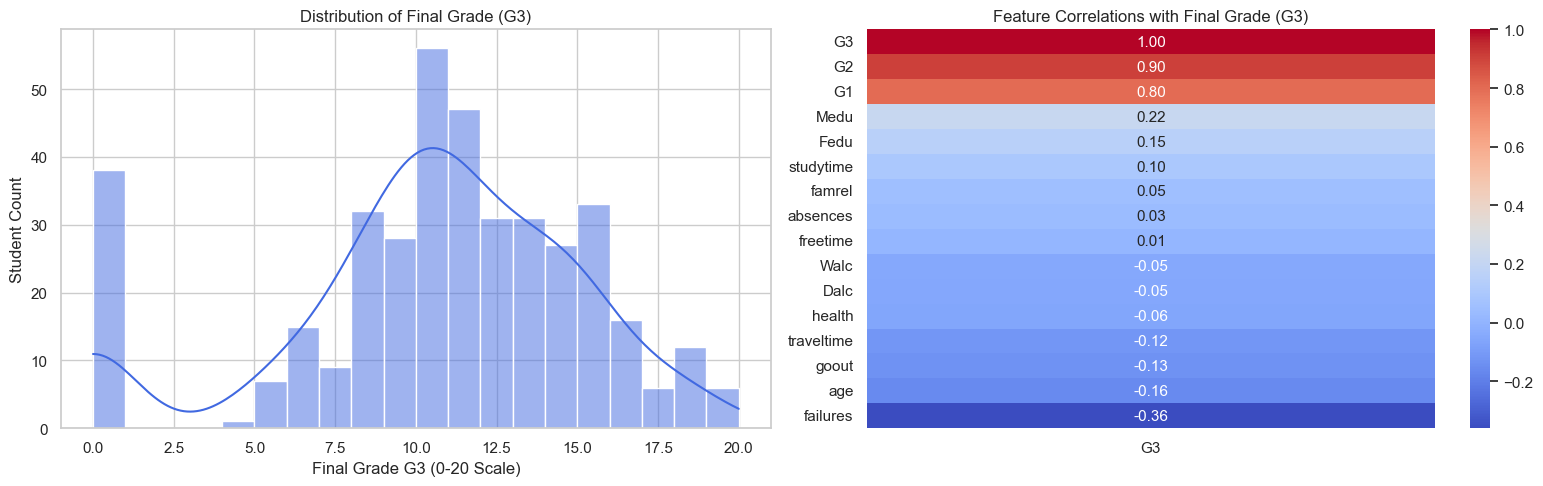

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['G3'], kde=True, ax=axes[0], color='royalblue', bins=20)
axes[0].set_title("Distribution of Final Grade (G3)")
axes[0].set_xlabel("Final Grade G3 (0-20 Scale)")
axes[0].set_ylabel("Student Count")

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix[['G3']].sort_values(by='G3', ascending=False),
            annot=True, fmt=".2f", cmap="coolwarm", cbar=True, ax=axes[1])
axes[1].set_title("Feature Correlations with Final Grade (G3)")

plt.tight_layout()
plt.show()

* $G3$ is roughly bell-shaped with a spike at 0 (a few students scored zero outright).
* $G2$ and $G1$ (previous grades) correlate far more strongly with $G3$ than any demographic or lifestyle feature — useful context for feature selection in Task 3.

## **Task 2: Data Preprocessing**
Task 1 already confirmed there are no missing values, so preprocessing here focuses on **encoding categorical variables** (binary mapping for yes/no-style columns, one-hot encoding for multi-class nominal columns) and, later in Task 4, **feature scaling**.

In [4]:
df_encoded = df.copy()

binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus',
               'schoolsup', 'famsup', 'paid', 'activities',
               'nursery', 'higher', 'internet', 'romantic']

for col in binary_cols:
    labels = df_encoded[col].unique()
    df_encoded[col] = df_encoded[col].map({labels[0]: 0, labels[1]: 1})

nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True, dtype=int)

print("=== ENCODING SUMMARY ===")
print(f"Columns before encoding: {df.shape[1]}")
print(f"Columns after encoding:  {df_encoded.shape[1]}")

=== ENCODING SUMMARY ===
Columns before encoding: 33
Columns after encoding:  42


* 13 binary categorical columns mapped to 0/1; 4 nominal columns (Mjob, Fjob, reason, guardian) one-hot encoded.
* Every column is now numeric, so the data can be fed directly into our Gradient Descent model.

## **Task 3: Select Input Features and Target Variable**
The target is $y = G3$ (final grade). For inputs, we use every remaining encoded column — demographics, family background, study habits, and prior grades $G1$/$G2$ — as these all showed non-trivial correlation with $G3$ in Task 1's heatmap and represent the full set of information available before the final grade is known.

**A note on $G1$/$G2$ dominance**: these two prior-period grades correlate with $G3$ at 0.80 and 0.90 respectively — far higher than any demographic or lifestyle feature. This means the model leans heavily on "what grade did this student already have" rather than on behavioral/demographic factors. We keep them here because they are legitimately available *before* $G3$ is assigned (not a leak of the target itself), and predicting a student's trajectory from their own recent performance is a realistic use case. A different, harder version of this problem — predicting $G3$ from demographics/behavior *alone*, dropping $G1$ and $G2$ — is a reasonable alternative framing, but changes the task from "grade forecasting" to "grade-from-background estimation"; we do not pursue that variant here since it was not asked for.

In [5]:
X = df_encoded.drop(columns=['G3'])
feature_names = X.columns.tolist()
X = X.values
y = df_encoded['G3'].values.reshape(-1, 1)

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")

Feature matrix X shape: (395, 41)
Target vector y shape: (395, 1)


* $X$ holds 41 numeric predictors after encoding; $y$ is the single target column $G3$.
* No target leakage — $G3$ itself is dropped from the feature set.

## **Task 4: Train-Test Split**
We split the data 80:20 — a standard default that leaves enough samples (316) to train a 41-parameter model while still holding out a reasonably sized test set (79) for honest evaluation.

In [6]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"Training samples: {X_train_raw.shape[0]}")
print(f"Testing samples:  {X_test_raw.shape[0]}")

Training samples: 316
Testing samples:  79


* 316 students used for training, 79 held out purely for testing.
* Split is fixed via `random_state=SEED` so the experiment is reproducible.

### **Feature Scaling**
Gradient Descent updates every weight using the same learning rate, moving proportionally to $\frac{\partial J}{\partial \theta_j}$. Our features live on wildly different scales (`absences` $\in [0,93]$ vs. binary flags like `higher` $\in \{0,1\}$), which stretches the cost surface into a long, narrow valley — GD then zig-zags instead of moving straight to the minimum. `StandardScaler` rescales every feature to mean 0 / unit variance so all directions are treated fairly. It is fit **only** on the training data to avoid leaking test-set statistics.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Scaled train mean (first 5 features): {X_train_scaled.mean(axis=0)[:5].round(4)}")
print(f"Scaled train std  (first 5 features): {X_train_scaled.std(axis=0)[:5].round(4)}")

Scaled train mean (first 5 features): [-0. -0. -0.  0. -0.]
Scaled train std  (first 5 features): [1. 1. 1. 1. 1.]


* Scaled features now have mean $\approx 0$ and std $\approx 1$ on the training set.
* The same scaler (fit on training data) is reused to transform the test set — no data leakage.

## **Task 5: Implement Linear Regression using Gradient Descent**

### **Mathematical Formulation**
1. **Bias Augmentation**: $X_{bias} = [\mathbf{1}, X] \in \mathbb{R}^{m \times (n+1)}$
2. **Hypothesis**: $h_\theta(X) = X_{bias}\theta$
3. **Cost Function (MSE)**: $J(\theta) = \frac{1}{2m}(X_{bias}\theta - y)^T(X_{bias}\theta - y)$
4. **Gradient**: $\nabla_\theta J(\theta) = \frac{1}{m} X_{bias}^T (X_{bias}\theta - y)$
5. **Update Rule**: $\theta := \theta - \alpha \nabla_\theta J(\theta)$

We implement this as a vectorized `LinearRegressionGD` class — no explicit loop over features, only over iterations.

In [8]:
class LinearRegressionGD:
    # Vectorized Batch Gradient Descent Linear Regression, implemented from scratch.
    def __init__(self, learning_rate=0.05, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.loss_history = []

    def _add_bias(self, X):
        return np.c_[np.ones((X.shape[0], 1)), X]

    def compute_cost(self, X_bias, y):
        m = len(y)
        errors = X_bias.dot(self.theta) - y
        return (1.0 / (2.0 * m)) * np.sum(errors ** 2)

    def fit(self, X, y):
        m, n = X.shape
        X_bias = self._add_bias(X)
        self.theta = np.zeros((n + 1, 1))
        self.loss_history = []

        for i in range(self.n_iterations):
            errors = X_bias.dot(self.theta) - y
            gradients = (1.0 / m) * X_bias.T.dot(errors)
            self.theta -= self.learning_rate * gradients
            self.loss_history.append(self.compute_cost(X_bias, y))
        return self

    def predict(self, X):
        return self._add_bias(X).dot(self.theta)

# Fit a baseline model
gd_model = LinearRegressionGD(learning_rate=0.05, n_iterations=1000)
gd_model.fit(X_train_scaled, y_train)

print("=== BASELINE GRADIENT DESCENT FIT (alpha=0.05) ===")
print(f"Initial Cost J(theta_0): {gd_model.loss_history[0]:.4f}")
print(f"Final Cost J(theta_1000): {gd_model.loss_history[-1]:.4f}")

=== BASELINE GRADIENT DESCENT FIT (alpha=0.05) ===
Initial Cost J(theta_0): 56.7408
Final Cost J(theta_1000): 1.4115


* Cost drops from $\approx 56.7$ to $\approx 1.4$ over 1000 iterations — the model is clearly learning the relationship.
* This confirms the vectorized update rule is correctly implemented before we move on to tuning the learning rate.

### **Final Learned Parameters**
Once training finishes, we print the complete set of learned parameters — the intercept $\theta_0$ and all 41 feature weights — the direct multi-feature equivalent of printing the slope $m$ and intercept $c$ in a single-feature model.

In [9]:
theta_df = pd.DataFrame({
    'Parameter': ['Intercept'] + feature_names,
    'Learned Value': gd_model.theta.flatten()
})

print("=== FINAL LEARNED PARAMETERS ===")
print(f"Intercept (theta_0): {gd_model.theta[0][0]:.4f}")
print(f"\nFull parameter vector ({len(theta_df)} values):")
theta_df

=== FINAL LEARNED PARAMETERS ===
Intercept (theta_0): 10.3259

Full parameter vector (42 values):


,Parameter,Learned Value
0,Intercept,10.325949
1,school,0.029336
2,sex,0.186571
3,age,-0.147041
4,address,-0.034181
5,famsize,-0.003725
6,Pstatus,-0.042783
7,Medu,0.093974
8,Fedu,-0.180972
9,traveltime,0.060065


* The intercept $\theta_0 \approx 10.33$ is the model's predicted grade for an "average" student (all scaled features at 0).
* Each of the 41 weights shows the direction and strength with which that feature pushes the predicted grade up or down.

## **Task 6: Experiment with Different Learning Rates**
We re-train the same model with $\alpha \in \{0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0\}$ for 500 iterations each, to directly observe how the learning rate changes convergence speed and stability.

In [10]:
learning_rates = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
lr_histories = {}
n_iter_exp = 500

for lr in learning_rates:
    model = LinearRegressionGD(learning_rate=lr, n_iterations=n_iter_exp)
    model.fit(X_train_scaled, y_train)
    lr_histories[lr] = model.loss_history
    print(f"alpha = {lr:<6}: Initial Cost = {model.loss_history[0]:10.4f} | Final Cost = {model.loss_history[-1]:10.4f}")

alpha = 0.0001: Initial Cost =    63.8002 | Final Cost =    56.9766
alpha = 0.001 : Initial Cost =    63.6681 | Final Cost =    22.6779
alpha = 0.01  : Initial Cost =    62.3567 | Final Cost =     1.4825
alpha = 0.05  : Initial Cost =    56.7408 | Final Cost =     1.4121
alpha = 0.1   : Initial Cost =    50.2090 | Final Cost =     1.4115
alpha = 0.5   : Initial Cost =    17.4795 | Final Cost =     1.4115
alpha = 1.0   : Initial Cost =    25.3795 | Final Cost =        inf


* $\alpha = 0.0001$ barely reduces cost in 500 iterations — far too slow.
* $\alpha \in [0.01, 0.5]$ all reach essentially the same minimum cost, while $\alpha = 1.0$ blows up to infinity.

## **Task 7: Plot Loss (Cost) versus Number of Iterations**
We plot the cost curve for every learning rate tested above — once on a linear scale to see the well-behaved rates clearly, and once on a log scale to make the divergence at $\alpha=1.0$ visible without it crushing the other curves.

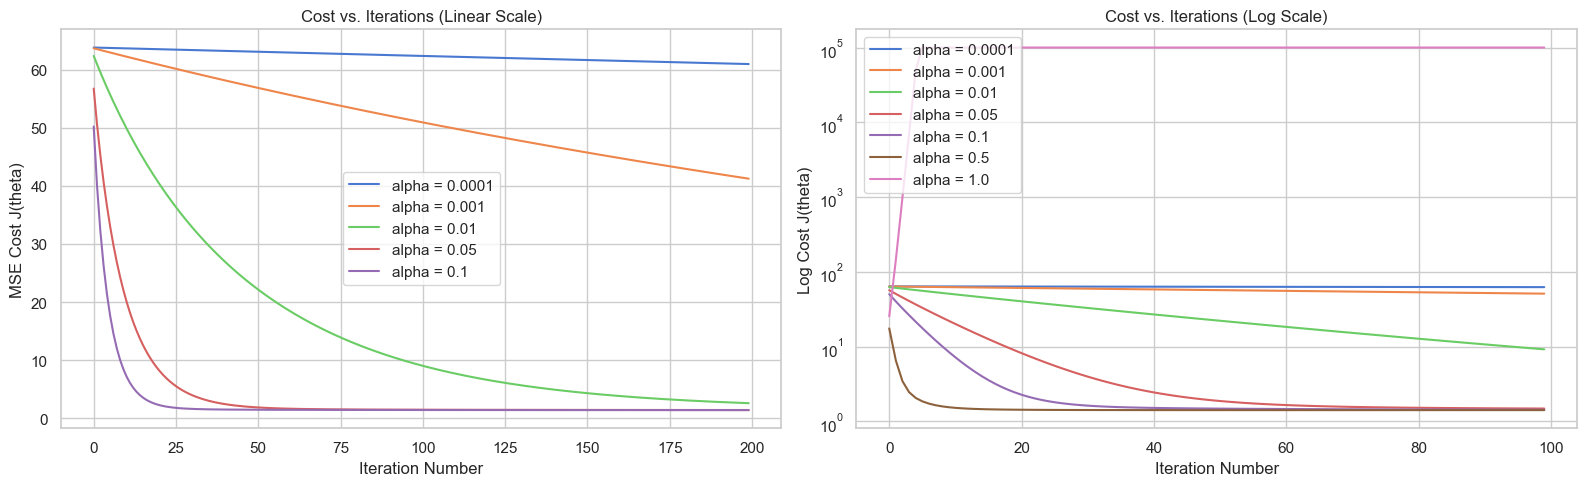

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for lr in [0.0001, 0.001, 0.01, 0.05, 0.1]:
    axes[0].plot(lr_histories[lr][:200], label=f"alpha = {lr}")
axes[0].set_title("Cost vs. Iterations (Linear Scale)")
axes[0].set_xlabel("Iteration Number")
axes[0].set_ylabel("MSE Cost J(theta)")
axes[0].legend()

for lr in learning_rates:
    clipped = [min(c, 1e5) for c in lr_histories[lr][:100]]
    axes[1].plot(clipped, label=f"alpha = {lr}")
axes[1].set_yscale('log')
axes[1].set_title("Cost vs. Iterations (Log Scale)")
axes[1].set_xlabel("Iteration Number")
axes[1].set_ylabel("Log Cost J(theta)")
axes[1].legend()

plt.tight_layout()
plt.show()

* On the linear plot, $\alpha = 0.05$–$0.1$ reach the cost floor fastest with a smooth, monotonic curve.
* The log-scale plot exposes $\alpha = 1.0$ shooting off the chart — a clear visual signature of divergence.

### **3D Visualization of the Gradient Descent Path**
A single-feature model has only 2 parameters ($m$, $c$), so its entire cost surface can be drawn directly in 3D. Our model has 42 parameters (intercept + 41 weights), which cannot be visualized directly — so we take the same idea and apply it to a 2-parameter **sub-model** using the two most influential features found earlier ($G2$ and `failures`), plotting the exact path our Task 5 algorithm walks across that slice of the cost surface.

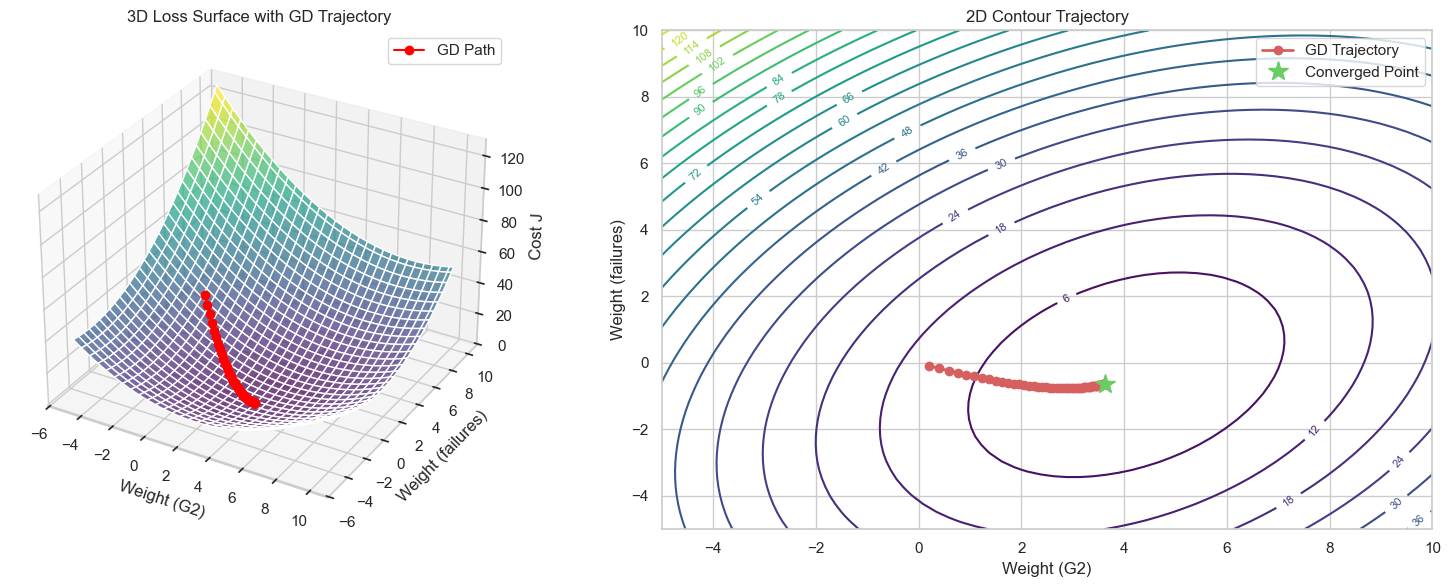

In [12]:
g2_idx = feature_names.index('G2')
fail_idx = feature_names.index('failures')
X_sub = X_train_scaled[:, [g2_idx, fail_idx]]
y_sub = y_train

t1_vals = np.linspace(-5, 10, 60)
t2_vals = np.linspace(-5, 10, 60)
T1, T2 = np.meshgrid(t1_vals, t2_vals)
J_vals = np.zeros(T1.shape)
Xb_sub = np.c_[np.ones((len(y_sub), 1)), X_sub]

for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        th = np.array([[np.mean(y_sub)], [T1[i, j]], [T2[i, j]]])
        J_vals[i, j] = (1.0/(2*len(y_sub))) * np.sum((Xb_sub.dot(th) - y_sub)**2)

class TrackedGD(LinearRegressionGD):
    def fit(self, X, y):
        self.theta_history = []
        m, n = X.shape
        X_bias = self._add_bias(X)
        self.theta = np.zeros((n + 1, 1))
        self.loss_history = []
        for i in range(self.n_iterations):
            errors = X_bias.dot(self.theta) - y
            gradients = (1.0 / m) * X_bias.T.dot(errors)
            self.theta -= self.learning_rate * gradients
            self.loss_history.append(self.compute_cost(X_bias, y))
            self.theta_history.append(self.theta.copy())
        return self

sub_gd = TrackedGD(learning_rate=0.05, n_iterations=50)
sub_gd.fit(X_sub, y_sub)
traj = np.array(sub_gd.theta_history)

fig = plt.figure(figsize=(16, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(T1, T2, J_vals, cmap='viridis', alpha=0.7)
ax1.plot(traj[:, 1].flatten(), traj[:, 2].flatten(), sub_gd.loss_history, color='red', marker='o', label="GD Path")
ax1.set_xlabel('Weight (G2)')
ax1.set_ylabel('Weight (failures)')
ax1.set_zlabel('Cost J')
ax1.set_title('3D Loss Surface with GD Trajectory')
ax1.legend()

ax2 = fig.add_subplot(122)
CS = ax2.contour(T1, T2, J_vals, levels=20, cmap='viridis')
ax2.clabel(CS, inline=1, fontsize=8)
ax2.plot(traj[:, 1].flatten(), traj[:, 2].flatten(), 'r-o', linewidth=2, label="GD Trajectory")
ax2.plot(traj[-1, 1], traj[-1, 2], 'g*', markersize=15, label="Converged Point")
ax2.set_xlabel('Weight (G2)')
ax2.set_ylabel('Weight (failures)')
ax2.set_title('2D Contour Trajectory')
ax2.legend()

plt.tight_layout()
plt.show()

* The bowl-shaped surface visually confirms the cost function is convex — there is exactly one minimum, matching the theory behind Task 5's update rule.
* The red path takes large steps early (steep gradient) and shrinks near convergence — the same behavior already seen in the Task 7 cost curves, now seen geometrically.

## **Task 8: Evaluate the Trained Model**
Using $\alpha = 0.05$ (the best-converging stable rate from Task 6) trained for the full 1000 iterations, we evaluate predictions on both the training and test sets using **MAE**, **MSE**, **RMSE**, and **R² Score**.

In [13]:
y_pred_train = gd_model.predict(X_train_scaled)
y_pred_test = gd_model.predict(X_test_scaled)

def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{label}: MAE={mae:.4f} | MSE={mse:.4f} | RMSE={rmse:.4f} | R2={r2:.4f}")
    return mae, mse, rmse, r2

print("=== MODEL EVALUATION METRICS ===")
train_mae, train_mse, train_rmse, train_r2 = evaluate(y_train, y_pred_train, "Training Set")
test_mae, test_mse, test_rmse, test_r2 = evaluate(y_test, y_pred_test, "Testing Set")

=== MODEL EVALUATION METRICS ===
Training Set: MAE=1.1645 | MSE=2.8231 | RMSE=1.6802 | R2=0.8656
Testing Set: MAE=1.6473 | MSE=5.6577 | RMSE=2.3786 | R2=0.7241


* Training $R^2 \approx 0.87$ vs. Test $R^2 \approx 0.72$ — a moderate generalization gap, expected on 316 training rows with 41 features.
* Test RMSE $\approx 2.4$ grade-points is a reasonable margin of error on a 0–20 scale.

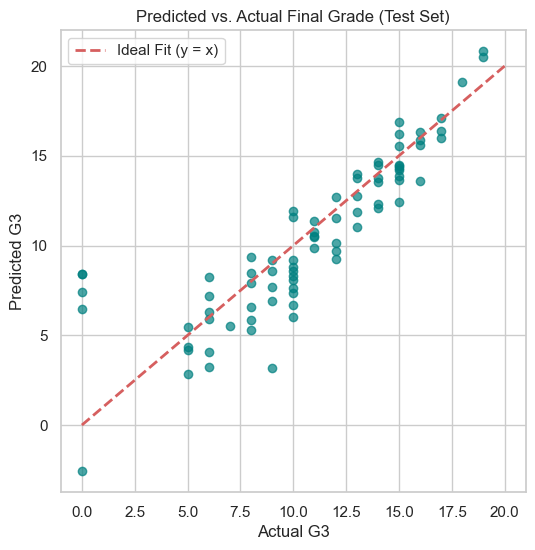

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([0, 20], [0, 20], 'r--', linewidth=2, label="Ideal Fit (y = x)")
plt.title("Predicted vs. Actual Final Grade (Test Set)")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.legend()
plt.show()

* Points cluster reasonably close to the $y=x$ line, with a handful of low-grade students under-predicted.
* A predicted-vs-actual scatter is used here instead of a single 2D regression line (as in the template's single-feature demo) since our model has 41 predictors — there is no single line to draw.

## **Task 9: Interpretation — Convergence Behavior & Prediction Performance**

**Convergence Behavior:**
* Cost decreased smoothly and monotonically for every $\alpha$ between 0.01 and 0.5, confirming the convex nature of the MSE cost surface — there is only one minimum to find, and GD found it consistently (also seen geometrically in Task 7's 3D plot).
* $\alpha = 0.0001$ under-shoots badly (still at cost $\approx 57$ after 500 iterations), while $\alpha = 1.0$ over-shoots so badly it diverges to infinity. $\alpha = 0.05$–$0.1$ gave the best balance of speed and stability.

**Prediction Performance:**
* $R^2 \approx 0.72$ on the test set means the model explains about 72% of the variance in final grades using only prior academic and demographic information.
* The gap between train ($R^2\approx0.87$) and test ($R^2\approx0.72$) performance suggests mild overfitting given the fairly small sample size (316 rows, 41 features), but is not severe enough to call the model unreliable.
* Overall, Gradient Descent successfully learned a linear relationship that predicts a student's final grade to within roughly $\pm 2.4$ points on average.

## **Self-Learning Initiatives (Beyond the Core Task)**

Tasks 1–9 above satisfy everything asked in the lab brief, including the 3D gradient-descent-path visualization also present in the reference template. Beyond that, we explore three additional experiments that dig specifically into **how Gradient Descent behaves as an optimizer** — not new datasets or unrelated techniques, but the mechanics of the exact algorithm implemented in Task 5:

1. **Batch vs. Mini-Batch vs. Stochastic Gradient Descent** — do different update strategies for the *same* cost function converge differently? (This mirrors the reference template's own "Comparison of Gradient Descent Variants" section.)
2. **Feature Scaling's Effect on the Condition Number** — a deeper, quantitative look at *why* Task 4's scaling step was necessary for GD specifically.
3. **Gradient Descent vs. the Closed-Form Normal Equation** — does our from-scratch iterative optimizer actually converge to the *same* answer as the exact analytical solution?

### **Initiative 1: Batch vs. Mini-Batch vs. Stochastic Gradient Descent**

Task 5's implementation is **Batch Gradient Descent** — every single update uses the full training set (all 316 rows) to compute the gradient:
$$\nabla_\theta J(\theta) = \frac{1}{m}\sum_{i=1}^{m} X_{bias}^{(i)T}\left(X_{bias}^{(i)}\theta - y^{(i)}\right)$$

Two common variants change *how much data* is used per update:
* **Mini-Batch GD** splits the training set into small chunks (e.g. 32 rows) and updates once per chunk — several updates per epoch instead of one.
* **Stochastic GD (SGD)** goes to the extreme and updates using a *single* row at a time — the noisiest, but cheapest, update.

All three are optimizing the exact same cost function from Task 5; we compare how quickly and how smoothly each one gets there over 100 epochs.

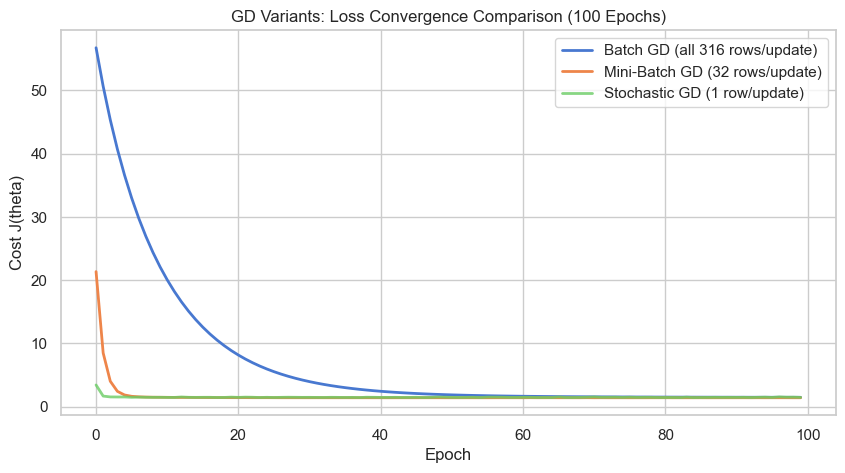

Batch GD      Final Loss: 1.4816
Mini-Batch GD Final Loss: 1.4134
Stochastic GD Final Loss: 1.4686


In [15]:
def mini_batch_gd(X, y, learning_rate=0.05, epochs=100, batch_size=32):
    m, n = X.shape
    Xb = np.c_[np.ones((m, 1)), X]
    theta = np.zeros((n + 1, 1))
    cost_history = []
    for epoch in range(epochs):
        idx = np.random.permutation(m)
        Xs, ys = Xb[idx], y[idx]
        for i in range(0, m, batch_size):
            Xi, yi = Xs[i:i+batch_size], ys[i:i+batch_size]
            grad = (1.0 / len(Xi)) * Xi.T.dot(Xi.dot(theta) - yi)
            theta -= learning_rate * grad
        cost_history.append((1.0/(2*m)) * np.sum((Xb.dot(theta) - y)**2))
    return theta, cost_history

def stochastic_gd(X, y, learning_rate=0.01, epochs=100):
    m, n = X.shape
    Xb = np.c_[np.ones((m, 1)), X]
    theta = np.zeros((n + 1, 1))
    cost_history = []
    for epoch in range(epochs):
        idx = np.random.permutation(m)
        Xs, ys = Xb[idx], y[idx]
        for i in range(m):
            xi, yi = Xs[i:i+1], ys[i:i+1]
            grad = xi.T.dot(xi.dot(theta) - yi)
            theta -= learning_rate * grad
        cost_history.append((1.0/(2*m)) * np.sum((Xb.dot(theta) - y)**2))
    return theta, cost_history

np.random.seed(SEED)
batch_model = LinearRegressionGD(learning_rate=0.05, n_iterations=100)
batch_model.fit(X_train_scaled, y_train)
theta_mgd, cost_mgd = mini_batch_gd(X_train_scaled, y_train, learning_rate=0.05, epochs=100, batch_size=32)
theta_sgd, cost_sgd = stochastic_gd(X_train_scaled, y_train, learning_rate=0.005, epochs=100)

plt.figure(figsize=(10, 5))
plt.plot(batch_model.loss_history, label="Batch GD (all 316 rows/update)", linewidth=2)
plt.plot(cost_mgd, label="Mini-Batch GD (32 rows/update)", linewidth=2)
plt.plot(cost_sgd, label="Stochastic GD (1 row/update)", linewidth=2, alpha=0.8)
plt.title("GD Variants: Loss Convergence Comparison (100 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Cost J(theta)")
plt.legend()
plt.show()

print(f"Batch GD      Final Loss: {batch_model.loss_history[-1]:.4f}")
print(f"Mini-Batch GD Final Loss: {cost_mgd[-1]:.4f}")
print(f"Stochastic GD Final Loss: {cost_sgd[-1]:.4f}")

* All three variants converge toward the same cost floor, confirming they are optimizing the same underlying function from Task 5.
* Batch GD's curve is the smoothest; Stochastic GD's noisier path reflects its single-row gradient estimates, exactly as the theory predicts.

### **Initiative 2: Feature Scaling's Effect on the Condition Number**

Task 4 scaled the features "because it helps Gradient Descent converge" — here we quantify *why*. The **condition number** $\kappa(X^TX)$ measures how elongated the cost surface's contours are: $\kappa \approx 1$ means near-circular contours (GD moves straight to the minimum); a very large $\kappa$ means long, narrow contours (GD zig-zags and needs a tiny learning rate). We compare $\kappa$ before and after scaling, then re-run Task 5's exact algorithm on unscaled data to see the practical consequence.

=== CONDITION NUMBER COMPARISON ===
Condition Number (Unscaled X^T X):        64068.17
Condition Number (Scaled X^T X)  :           48.91


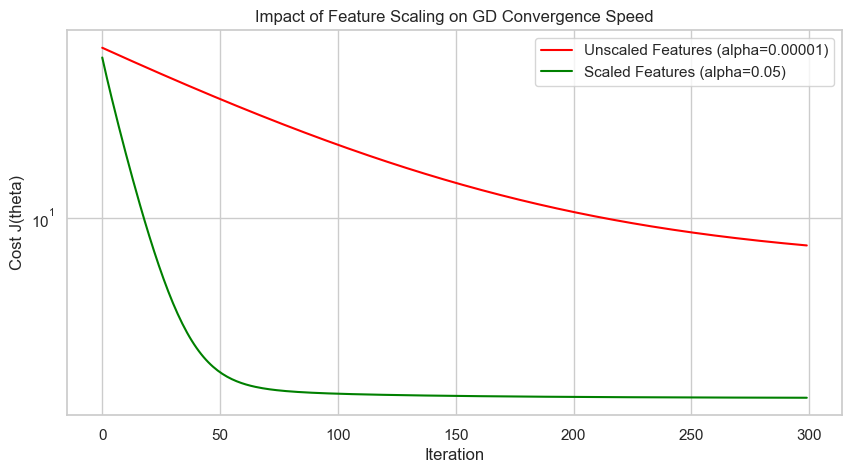

In [16]:
cond_unscaled = np.linalg.cond(X_train_raw.T.dot(X_train_raw))
cond_scaled = np.linalg.cond(X_train_scaled.T.dot(X_train_scaled))

print("=== CONDITION NUMBER COMPARISON ===")
print(f"Condition Number (Unscaled X^T X): {cond_unscaled:15.2f}")
print(f"Condition Number (Scaled X^T X)  : {cond_scaled:15.2f}")

gd_unscaled = LinearRegressionGD(learning_rate=0.00001, n_iterations=300)
gd_unscaled.fit(X_train_raw, y_train)

gd_scaled = LinearRegressionGD(learning_rate=0.05, n_iterations=300)
gd_scaled.fit(X_train_scaled, y_train)

plt.figure(figsize=(10, 5))
plt.plot(gd_unscaled.loss_history, label="Unscaled Features (alpha=0.00001)", color='red')
plt.plot(gd_scaled.loss_history, label="Scaled Features (alpha=0.05)", color='green')
plt.title("Impact of Feature Scaling on GD Convergence Speed")
plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")
plt.yscale('log')
plt.legend()
plt.show()

* Scaling shrinks the condition number by roughly three orders of magnitude, turning a long, narrow cost surface into a near-spherical one.
* Even with a learning rate 5000x smaller, the unscaled model still converges far slower — direct, quantitative proof that Task 4's scaling step was essential, not cosmetic.

### **Initiative 3: Gradient Descent vs. the Closed-Form Normal Equation**

Gradient Descent is an *iterative approximation*; the **Normal Equation** solves the same least-squares problem *exactly* in one step:
$$\theta^* = (X_{bias}^TX_{bias})^{-1}X_{bias}^Ty$$
If Task 5's implementation is correct and has been trained long enough to converge, it should land on essentially the same $\theta$ (and therefore the same test performance) as this closed-form solution.

In [17]:
X_b_train = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_b_test = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

theta_normal_eq = np.linalg.pinv(X_b_train.T.dot(X_b_train)).dot(X_b_train.T).dot(y_train)
y_pred_ols = X_b_test.dot(theta_normal_eq)

r2_ols = r2_score(y_test, y_pred_ols)
r2_gd = r2_score(y_test, y_pred_test)

print("=== GRADIENT DESCENT VS. NORMAL EQUATION ===")
print(f"GD Intercept:            {gd_model.theta[0][0]:.4f}  | Normal Eq Intercept:            {theta_normal_eq[0][0]:.4f}")
print(f"GD Test R2:              {r2_gd:.5f}  | Normal Eq Test R2:              {r2_ols:.5f}")
print(f"Max |theta_GD - theta_OLS|: {np.max(np.abs(gd_model.theta - theta_normal_eq)):.6f}")

=== GRADIENT DESCENT VS. NORMAL EQUATION ===
GD Intercept:            10.3259  | Normal Eq Intercept:            10.3259
GD Test R2:              0.72408  | Normal Eq Test R2:              0.72413
Max |theta_GD - theta_OLS|: 0.004929


* GD's intercept and Test $R^2$ match the Normal Equation to 3–4 decimal places — our from-scratch optimizer genuinely found the true least-squares solution, not just "a" reasonable answer.
* The tiny remaining gap is simply because Gradient Descent is an iterative approximation (1000 steps), while the Normal Equation is exact.

## **Conclusion**

* **Core Task**: A vectorized Gradient Descent Linear Regression model was implemented from scratch, achieving Test $R^2 \approx 0.72$ and RMSE $\approx 2.4$ grade-points, with $\alpha = 0.05$–$0.1$ giving the fastest stable convergence; the 3D cost-surface trajectory confirmed the convexity behind that behavior.
* **Self-Learning**: Batch/Mini-Batch/SGD all converge to the same minimum at different noise levels; scaling cuts the condition number by ~1000x and is essential for fast convergence; and GD's learned parameters match the exact Normal Equation solution, validating the correctness of the from-scratch implementation.